## Performing analysis on dataset again while dealing with outliers

In [163]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("Wellbeing_and_lifestyle_data_Kaggle (Dataset1).csv")

## 1) Exploring dataset

In [164]:
df.head()

,Timestamp,FRUITS_VEGGIES,DAILY_STRESS,PLACES_VISITED,CORE_CIRCLE,SUPPORTING_OTHERS,SOCIAL_NETWORK,ACHIEVEMENT,DONATION,BMI_RANGE,...,SLEEP_HOURS,LOST_VACATION,DAILY_SHOUTING,SUFFICIENT_INCOME,PERSONAL_AWARDS,TIME_FOR_PASSION,WEEKLY_MEDITATION,AGE,GENDER,WORK_LIFE_BALANCE_SCORE
0,07-07-2015,3,2,2,5,0,5,2,0,1,...,7,5,5,1,4,0,5,36 to 50,Female,609.5
1,07-07-2015,2,3,4,3,8,10,5,2,2,...,8,2,2,2,3,2,6,36 to 50,Female,655.6
2,07-07-2015,2,3,3,4,4,10,3,2,2,...,8,10,2,2,4,8,3,36 to 50,Female,631.6
3,07-07-2015,3,3,10,3,10,7,2,5,2,...,5,7,5,1,5,2,0,51 or more,Female,622.7
4,07-07-2015,5,1,3,3,10,4,2,4,2,...,7,0,0,2,8,1,5,51 or more,Female,663.9


In [165]:
print(f" Shape of dataset is : {df.shape}")

 Shape of dataset is : (15972, 24)


In [166]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 15972 entries, 0 to 15971
Data columns (total 24 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Timestamp                15972 non-null  str    
 1   FRUITS_VEGGIES           15972 non-null  int64  
 2   DAILY_STRESS             15972 non-null  str    
 3   PLACES_VISITED           15972 non-null  int64  
 4   CORE_CIRCLE              15972 non-null  int64  
 5   SUPPORTING_OTHERS        15972 non-null  int64  
 6   SOCIAL_NETWORK           15972 non-null  int64  
 7   ACHIEVEMENT              15972 non-null  int64  
 8   DONATION                 15972 non-null  int64  
 9   BMI_RANGE                15972 non-null  int64  
 10  TODO_COMPLETED           15972 non-null  int64  
 11  FLOW                     15972 non-null  int64  
 12  DAILY_STEPS              15972 non-null  int64  
 13  LIVE_VISION              15972 non-null  int64  
 14  SLEEP_HOURS              15972 no

In [167]:
# Dropping the timestamp column as it is not contributing in our analysis
df.drop(columns="Timestamp", inplace=True)

In [168]:
print(" Printing the unique values of every column :")
for col in df.columns:
    print(f" The unique values are : {df[col].unique()}")

 Printing the unique values of every column :
 The unique values are : [3 2 5 4 1 0]
 The unique values are : <StringArray>
['2', '3', '1', '4', '5', '0', '01-01-2000']
Length: 7, dtype: str
 The unique values are : [ 2  4  3 10  5  6  7  0  8  1  9]
 The unique values are : [ 5  3  4  9  6  7  8 10  2  1  0]
 The unique values are : [ 0  8  4 10  5  3  1  2  6  7  9]
 The unique values are : [ 5 10  7  4  3  1  2  8  6  9  0]
 The unique values are : [ 2  5  3  4  0  1  6 10  8  7  9]
 The unique values are : [0 2 5 4 3 1]
 The unique values are : [1 2]
 The unique values are : [ 6  5  2  3  8 10  7  4  1  0  9]
 The unique values are : [ 4  2  5  0  1  8  7  6  3 10  9]
 The unique values are : [ 5  4  7  8  1  3  6  2 10  9]
 The unique values are : [ 0  5 10  4  2  1  6  3  8  9  7]
 The unique values are : [ 7  8  5  6 10  9  4  3  2  1]
 The unique values are : [ 5  2 10  7  0  3  1  4  8  6  9]
 The unique values are : [ 5  2  0  3  1  7  6  4 10  8  9]
 The unique values are : 

* **Statistical summary**

In [169]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
FRUITS_VEGGIES,15972.0,2.922677,1.442694,0.0,2.0,3.0,4.0,5.0
PLACES_VISITED,15972.0,5.232970,3.311912,0.0,2.0,5.0,8.0,10.0
CORE_CIRCLE,15972.0,5.508077,2.840334,0.0,3.0,5.0,8.0,10.0
SUPPORTING_OTHERS,15972.0,5.616454,3.242021,0.0,3.0,5.0,10.0,10.0
SOCIAL_NETWORK,15972.0,6.474267,3.086672,0.0,4.0,6.0,10.0,10.0
ACHIEVEMENT,15972.0,4.000751,2.755837,0.0,2.0,3.0,6.0,10.0
DONATION,15972.0,2.715314,1.851586,0.0,1.0,3.0,5.0,5.0
BMI_RANGE,15972.0,1.410656,0.491968,1.0,1.0,1.0,2.0,2.0
TODO_COMPLETED,15972.0,5.745993,2.624097,0.0,4.0,6.0,8.0,10.0
FLOW,15972.0,3.194778,2.357518,0.0,1.0,3.0,5.0,10.0


In [170]:
print(f"Total null values in the dataset are : {df.isnull().sum()}")
print(f"\n\nTotal duplicates values in the dataset are: {df.duplicated().sum()}")

Total null values in the dataset are : FRUITS_VEGGIES             0
DAILY_STRESS               0
PLACES_VISITED             0
CORE_CIRCLE                0
SUPPORTING_OTHERS          0
SOCIAL_NETWORK             0
ACHIEVEMENT                0
DONATION                   0
BMI_RANGE                  0
TODO_COMPLETED             0
FLOW                       0
DAILY_STEPS                0
LIVE_VISION                0
SLEEP_HOURS                0
LOST_VACATION              0
DAILY_SHOUTING             0
SUFFICIENT_INCOME          0
PERSONAL_AWARDS            0
TIME_FOR_PASSION           0
WEEKLY_MEDITATION          0
AGE                        0
GENDER                     0
WORK_LIFE_BALANCE_SCORE    0
dtype: int64


Total duplicates values in the dataset are: 683


# cleaning and encoding values


In [171]:
df = df[df["DAILY_STRESS"] != '01-01-2000']

In [172]:
df['AGE'] = df['AGE'].map({ "Less than 20": 0, "21 to 35": 1, "36 to 50": 2, "51 or more": 3 })
df = pd.get_dummies(df, columns=['GENDER'], drop_first=True)

df['DAILY_STRESS'] = df['DAILY_STRESS'].astype("int64")



In [173]:
df.info()

<class 'pandas.DataFrame'>
Index: 15971 entries, 0 to 15971
Data columns (total 23 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   FRUITS_VEGGIES           15971 non-null  int64  
 1   DAILY_STRESS             15971 non-null  int64  
 2   PLACES_VISITED           15971 non-null  int64  
 3   CORE_CIRCLE              15971 non-null  int64  
 4   SUPPORTING_OTHERS        15971 non-null  int64  
 5   SOCIAL_NETWORK           15971 non-null  int64  
 6   ACHIEVEMENT              15971 non-null  int64  
 7   DONATION                 15971 non-null  int64  
 8   BMI_RANGE                15971 non-null  int64  
 9   TODO_COMPLETED           15971 non-null  int64  
 10  FLOW                     15971 non-null  int64  
 11  DAILY_STEPS              15971 non-null  int64  
 12  LIVE_VISION              15971 non-null  int64  
 13  SLEEP_HOURS              15971 non-null  int64  
 14  LOST_VACATION            15971 non-nul

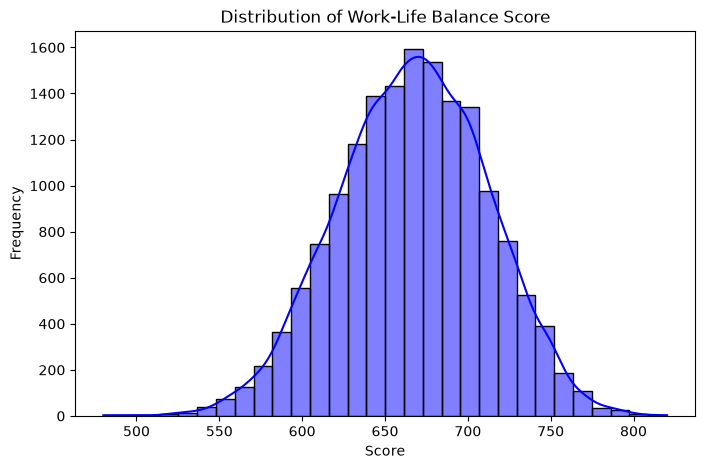

In [174]:
# 1. Univariate: Distribution of the Target Variable
plt.figure(figsize=(8, 5))
sns.histplot(df['WORK_LIFE_BALANCE_SCORE'], bins=30, kde=True, color='blue')
plt.title('Distribution of Work-Life Balance Score')
plt.xlabel('Score')
plt.ylabel('Frequency')
plt.show()

In [175]:
target = 'WORK_LIFE_BALANCE_SCORE'
numerical_features = df.select_dtypes(include=['int64', 'float64','bool']).columns.drop(target)
len(numerical_features)

22

In [176]:
df[numerical_features].agg([
    'mean',
    'median',
    'std',
    'min',
    'max',
    'skew',
    'kurt'
]).T

,mean,median,std,min,max,skew,kurt
FRUITS_VEGGIES,2.922672,3.0,1.442739,0.0,5.0,-0.05097,-1.007162
DAILY_STRESS,2.791685,3.0,1.367801,0.0,5.0,-0.080529,-0.798375
PLACES_VISITED,5.233235,5.0,3.311847,0.0,10.0,0.170406,-1.252036
CORE_CIRCLE,5.508296,5.0,2.840287,0.0,10.0,0.202339,-0.966744
SUPPORTING_OTHERS,5.616179,5.0,3.241937,0.0,10.0,0.055772,-1.270486
SOCIAL_NETWORK,6.474047,6.0,3.086643,0.0,10.0,-0.175079,-1.370395
ACHIEVEMENT,4.000689,3.0,2.755912,0.0,10.0,0.628937,-0.355081
DONATION,2.715171,3.0,1.851556,0.0,5.0,-0.047805,-1.439437
BMI_RANGE,1.410619,1.0,0.491962,1.0,2.0,0.36341,-1.868167
TODO_COMPLETED,5.745977,6.0,2.624179,0.0,10.0,-0.356052,-0.704685


C:\Users\adity\AppData\Local\Temp\ipykernel_1244\1961512717.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df[feature], y=df[target], palette="viridis")
C:\Users\adity\AppData\Local\Temp\ipykernel_1244\1961512717.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df[feature], y=df[target], palette="viridis")
C:\Users\adity\AppData\Local\Temp\ipykernel_1244\1961512717.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df[feature], y=df[target], palette="viridis")
C:\Users\adity\AppData\Local\Temp\ipykernel_1244\1961512717.py:9: F

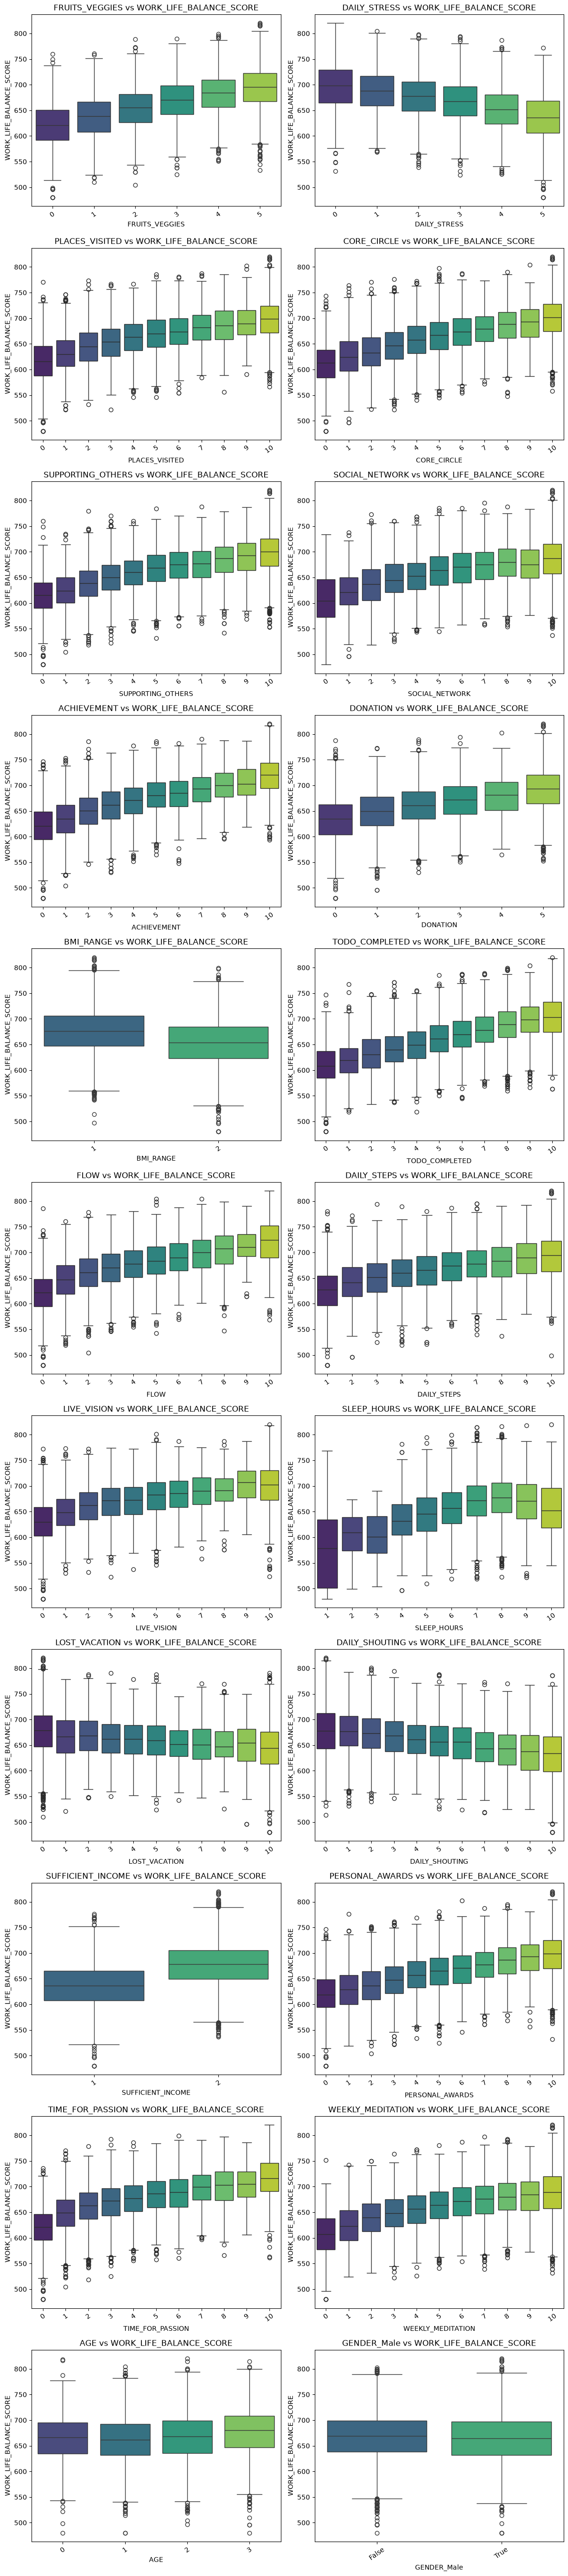

In [177]:
#Creating the boxplots 

plt.figure(figsize=(12, 6 * 9))

for i, feature in enumerate(numerical_features):
    plt.subplot(11, 2, i+1)
    
    # Create a boxplot
    sns.boxplot(x=df[feature], y=df[target], palette="viridis")
    plt.title(f'{feature} vs {target}')
    plt.xlabel(feature)
    plt.ylabel(target)
    plt.xticks(rotation=35)

plt.tight_layout()
plt.show()

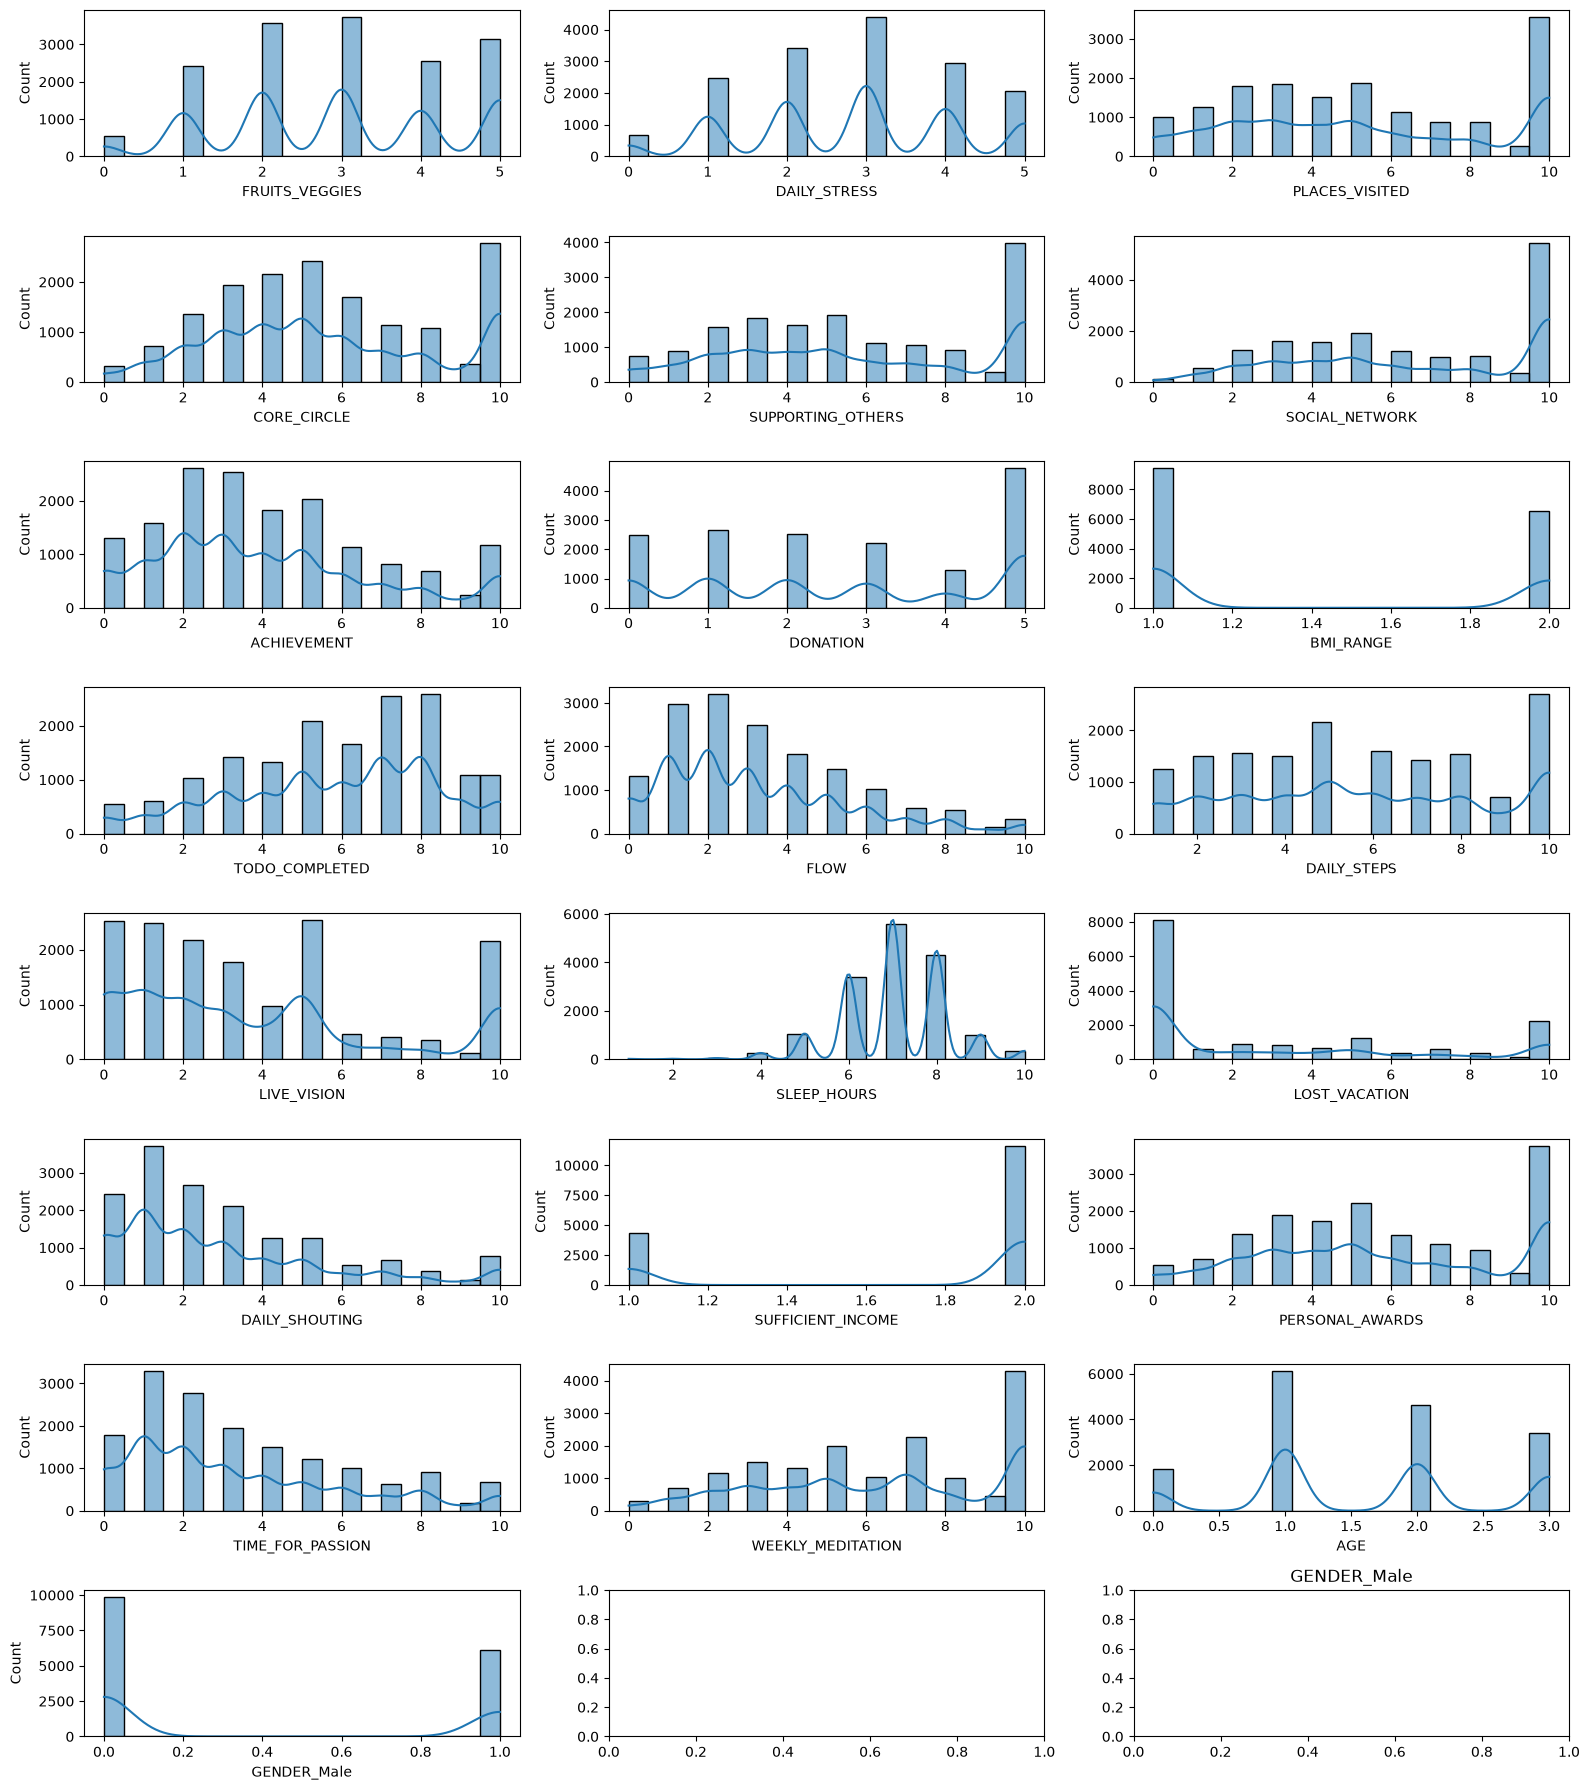

In [178]:
#Creating histograms for plotting graph for frequencies of selected numerical columns 
fig, axes = plt.subplots(8,3,figsize = (16,18))

for ax, col in zip(axes.flatten(), numerical_features):
    sns.histplot(df[col], bins = 20, kde  = True, ax = ax)
    plt.title(col)

plt.tight_layout()
plt.show()

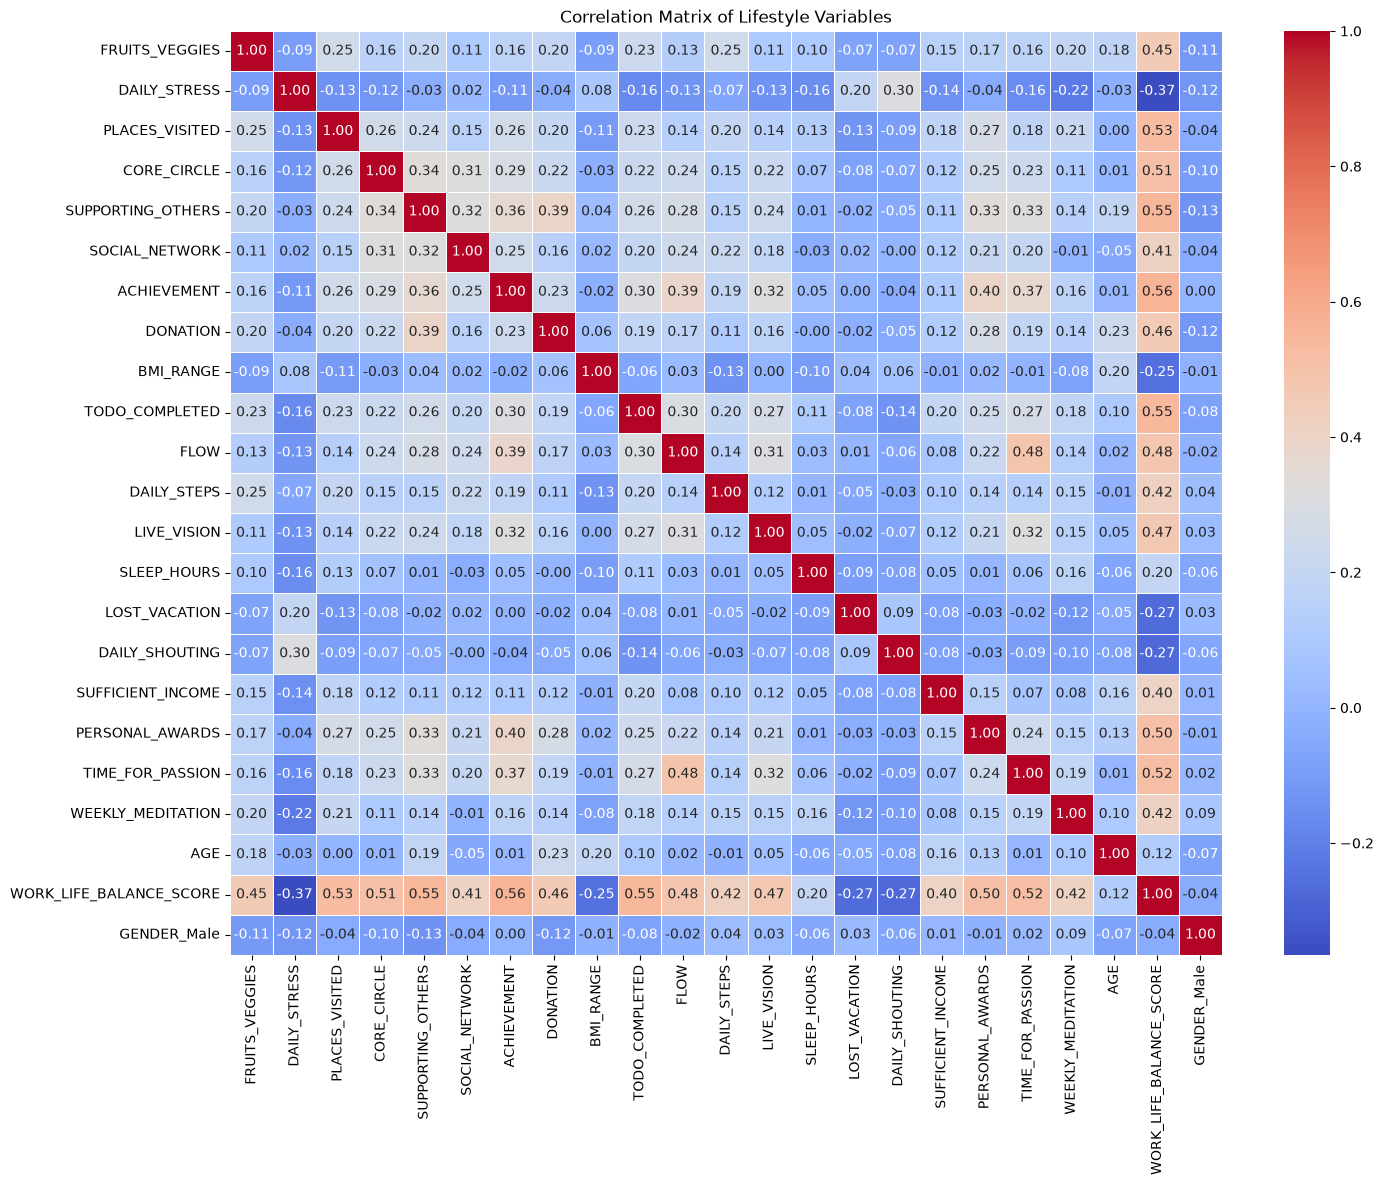

In [179]:
#Plotting the corelation matrix to show corelation between attributes

correlated = df.corr()
plt.figure(figsize= (16,12))
sns.heatmap(correlated, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix of Lifestyle Variables')
plt.show()



# Detecting the outliers present in the data

In [180]:
def detect_outliers_iqr(data, column):

    Q1 = data[column].quantile(0.30)
    Q3 = data[column].quantile(0.70)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = data[
        (data[column] < lower) |
        (data[column] > upper)
    ]

    return outliers

In [181]:
outliers = []

for col in numerical_features[:-1]:
    olr = detect_outliers_iqr(df, col)
    outliers.append({
        "feature" : col,
        "count" : len(olr),
        "percentage" : round(len(olr)/len(df) * 100,2)
    })

outliers_df = pd.DataFrame(outliers)

print(outliers_df)

              feature  count  percentage
0      FRUITS_VEGGIES      0        0.00
1        DAILY_STRESS      0        0.00
2      PLACES_VISITED      0        0.00
3         CORE_CIRCLE      0        0.00
4   SUPPORTING_OTHERS      0        0.00
5      SOCIAL_NETWORK      0        0.00
6         ACHIEVEMENT   1170        7.33
7            DONATION      0        0.00
8           BMI_RANGE      0        0.00
9      TODO_COMPLETED      0        0.00
10               FLOW   1043        6.53
11        DAILY_STEPS      0        0.00
12        LIVE_VISION      0        0.00
13        SLEEP_HOURS   1698       10.63
14      LOST_VACATION      0        0.00
15     DAILY_SHOUTING    930        5.82
16  SUFFICIENT_INCOME   4329       27.11
17    PERSONAL_AWARDS      0        0.00
18   TIME_FOR_PASSION    875        5.48
19  WEEKLY_MEDITATION      0        0.00
20                AGE      0        0.00


In [182]:
from scipy.stats import zscore

z_scores = df[numerical_features].apply(zscore)

outliers_z_p = (abs(z_scores) > 3)
outliers_z_n = (abs(z_scores) < -3)

print(outliers_z_p.sum())
print('\n \n \n')
print(outliers_z_n.sum())

FRUITS_VEGGIES        0
DAILY_STRESS          0
PLACES_VISITED        0
CORE_CIRCLE           0
SUPPORTING_OTHERS     0
SOCIAL_NETWORK        0
ACHIEVEMENT           0
DONATION              0
BMI_RANGE             0
TODO_COMPLETED        0
FLOW                  0
DAILY_STEPS           0
LIVE_VISION           0
SLEEP_HOURS          88
LOST_VACATION         0
DAILY_SHOUTING        0
SUFFICIENT_INCOME     0
PERSONAL_AWARDS       0
TIME_FOR_PASSION      0
WEEKLY_MEDITATION     0
AGE                   0
GENDER_Male           0
dtype: int64

 
 

FRUITS_VEGGIES       0
DAILY_STRESS         0
PLACES_VISITED       0
CORE_CIRCLE          0
SUPPORTING_OTHERS    0
SOCIAL_NETWORK       0
ACHIEVEMENT          0
DONATION             0
BMI_RANGE            0
TODO_COMPLETED       0
FLOW                 0
DAILY_STEPS          0
LIVE_VISION          0
SLEEP_HOURS          0
LOST_VACATION        0
DAILY_SHOUTING       0
SUFFICIENT_INCOME    0
PERSONAL_AWARDS      0
TIME_FOR_PASSION     0
WEEKLY_MEDITATIO

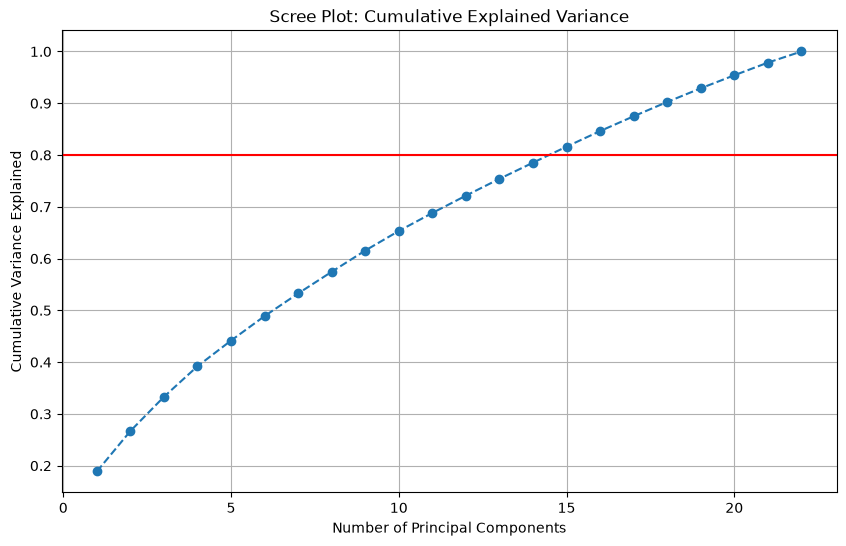


--- Feature importance in Principal Component 1 ---
ACHIEVEMENT          0.315552
SUPPORTING_OTHERS    0.307500
TIME_FOR_PASSION     0.290341
dtype: float64
LOST_VACATION    -0.066712
DAILY_SHOUTING   -0.095885
DAILY_STRESS     -0.138530
dtype: float64


In [183]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Assuming 'X' is your dataframe of features (excluding the target variable)
# 1. Standardize the data (PCA requires this strictly)

X = df.drop(columns=['WORK_LIFE_BALANCE_SCORE'])
y = df['WORK_LIFE_BALANCE_SCORE']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


# 2. Fit PCA on all components to see variance distribution
pca_full = PCA()
pca_full.fit_transform(X_scaled)

# 3. Calculate Explained Variance
explained_variance = pca_full.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

# 4. Plot the Scree Plot
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(explained_variance) + 1), cumulative_variance, marker='o', linestyle='--')
plt.axhline(y=0.80, color='r', linestyle='-') # 80% variance threshold
plt.title('Scree Plot: Cumulative Explained Variance')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Variance Explained')
plt.grid()
plt.show()

# 5. Extract feature weights for PC1 to see what it represents
pc1_weights = pd.Series(pca_full.components_[0], index=X.columns).sort_values(ascending=False)
print("\n--- Feature importance in Principal Component 1 ---")
print(pc1_weights.head(3)) # Top 3 positive contributors
print(pc1_weights.tail(3)) # Top 3 negative contributors

In [184]:
PCA_DF = pd.DataFrame(data = pca_full.transform(X_scaled)[:, :3], columns=['PC1', 'PC2', 'PC3'])
PCA_DF['Target'] = y.values

print(PCA_DF.head(3))
print(PCA_DF.tail(3))

        PC1       PC2       PC3  Target
0 -2.489504 -0.409906 -0.392464   609.5
1 -0.317129  0.449355  0.633657   655.6
2 -0.897237  1.371032 -0.367645   631.6
            PC1       PC2       PC3  Target
15968  1.648318 -0.275382  0.277992   716.6
15969  0.683185 -1.083738 -1.949481   682.0
15970  0.081279  1.256140 -0.485676   651.4


Variance explained by PC1: 18.88%
Variance explained by PC2: 7.82%
Total variance captured in this 2D plot: 26.69%


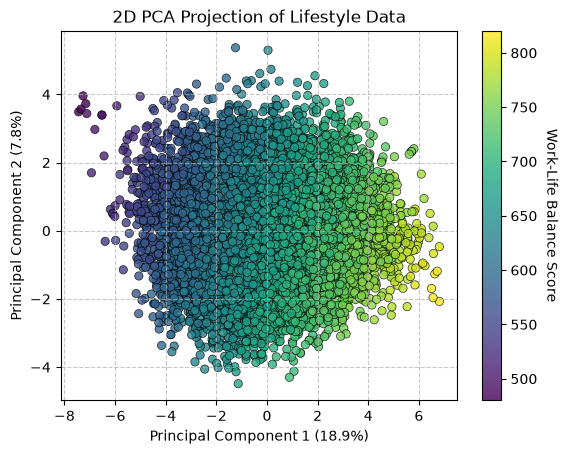

In [185]:
var_explained = pca_full.explained_variance_ratio_
print(f"Variance explained by PC1: {var_explained[0]*100:.2f}%")
print(f"Variance explained by PC2: {var_explained[1]*100:.2f}%")
print(f"Total variance captured in this 2D plot: {(var_explained[0]+var_explained[1])*100:.2f}%")
scatter = plt.scatter(PCA_DF['PC1'], PCA_DF['PC2'], c=PCA_DF['Target'], cmap='viridis', 
                      alpha=0.8, # Make dots slightly transparent to see overlapping
                      edgecolors='black', 
                      linewidth=0.5)

# Add a color bar to explain the colors
cbar = plt.colorbar(scatter)
cbar.set_label('Work-Life Balance Score', rotation=270, labelpad=15)

# Labels and Title
plt.xlabel(f'Principal Component 1 ({var_explained[0]*100:.1f}%)')
plt.ylabel(f'Principal Component 2 ({var_explained[1]*100:.1f}%)')
plt.title('2D PCA Projection of Lifestyle Data')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

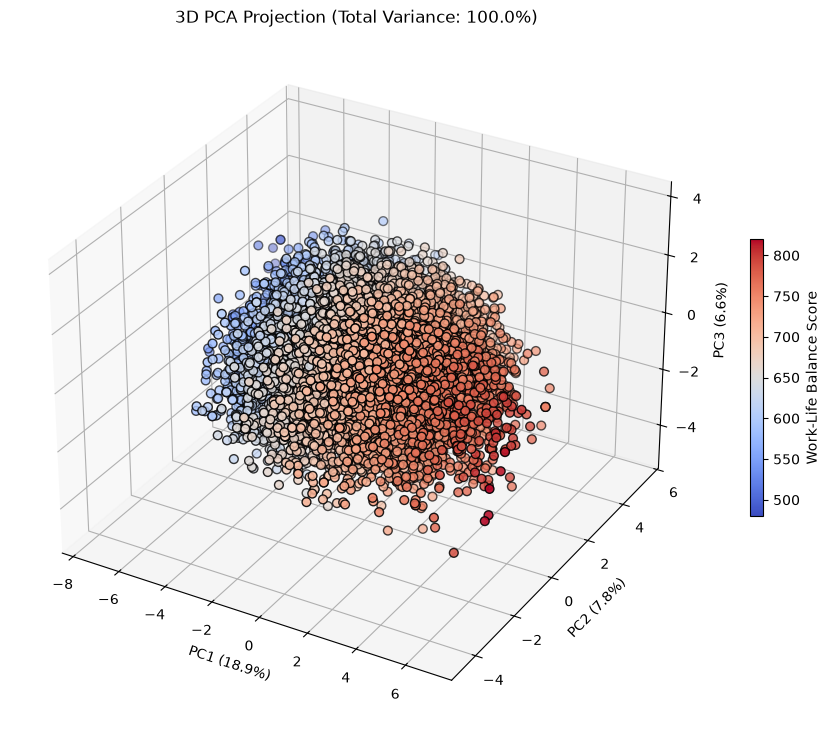

In [186]:
# Plot 3D
fig = plt.figure(figsize=(12, 9))
ax = fig.add_subplot(111, projection='3d')

# Scatter plot
scatter = ax.scatter(PCA_DF['PC1'], PCA_DF['PC2'], PCA_DF['PC3'], 
                     c=PCA_DF['Target'], cmap='coolwarm', 
                     alpha=1, edgecolors='black', s=40)

# ax.xaxis.set_pane_color((0.1, 0.1, 0.1, 0.5))  # Light gray background for better visibility
# ax.yaxis.set_pane_color((0.1, 0.1, 0.1, 0.5))  # Light gray background for better visibility
# ax.zaxis.set_pane_color((0.1, 0.1, 0.1, 0.5))  # Light gray background for better visibility
ax.set_xlabel(f'PC1 ({var_explained[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({var_explained[1]*100:.1f}%)')
ax.set_zlabel(f'PC3 ({var_explained[2]*100:.1f}%)')
plt.title(f'3D PCA Projection (Total Variance: {sum(var_explained)*100:.1f}%)')
fig.colorbar(scatter, label='Work-Life Balance Score', shrink=0.4)
plt.show()

In [187]:
# pca_5d = PCA(n_components=5)
# components_5d = pca_5d.fit_transform(X_scaled)

# # Create 5D DataFrame
# df_5d = pd.DataFrame(data=components_5d, columns=['PC1', 'PC2', 'PC3', 'PC4', 'PC5'])
# df_5d['Target'] = y.values

# # Plot Pairplot
# plt.figure(figsize=(15, 15))
# # We use a pairplot to compare every PC against every other PC
# sns.pairplot(df_5d, hue='Target', palette='viridis', corner=True, 
#              plot_kws={'alpha': 0.9, 's': 40, 'edgecolor': 'w'})
# plt.suptitle('Pairwise Relationships of Top 5 Principal Components', y=1.02)

In [188]:
# g = sns.pairplot(df_5d, diag_kind="kde")
# g.map_lower(sns.kdeplot, levels=4, color=".2")

In [189]:
# 1. Engineer: Psychological Stress Load
# Higher score = Worse psychological regulation
df['PSYCH_STRESS_LOAD'] = df['DAILY_STRESS'] + df['DAILY_SHOUTING'] - df['WEEKLY_MEDITATION']

# 2. Engineer: Social Isolation Index
# We invert the sum so that a HIGHER score means MORE isolation
# Added +1 to denominator to prevent division by zero
support = df['CORE_CIRCLE'] + df['SOCIAL_NETWORK']

df['SOCIAL_ISOLATION_INDEX'] = (
    support.max() - support
)
# df['SOCIAL_ISOLATION_INDEX'] = round(1 / (df['CORE_CIRCLE'] + df['SOCIAL_NETWORK'] + 1),3)

# 3. Engineer: Metabolic Risk Proxy
# High BMI combined with low steps. 
# Added +1 to steps to prevent division by zero (if a user has 0 steps)
# Note: Adjust 'BMI_RANGE' to whatever your specific column name is after dummy encoding
df['METABOLIC_RISK_PROXY'] = round(df['BMI_RANGE'] / (df['DAILY_STEPS'] + 1), 3)

df['SATISFACTION_SCORE'] = df['SUFFICIENT_INCOME'] + df['TIME_FOR_PASSION'] - df['LOST_VACATION']

# 4. Check for Multicollinearity in the new feature set
print("Checking correlations of engineered features with the target:")
new_features = ['PSYCH_STRESS_LOAD', 'SOCIAL_ISOLATION_INDEX', 'METABOLIC_RISK_PROXY','SATISFACTION_SCORE', 'WORK_LIFE_BALANCE_SCORE']
print(df[new_features].corr()['WORK_LIFE_BALANCE_SCORE'])

Checking correlations of engineered features with the target:
PSYCH_STRESS_LOAD         -0.510362
SOCIAL_ISOLATION_INDEX    -0.566053
METABOLIC_RISK_PROXY      -0.433564
SATISFACTION_SCORE         0.547674
WORK_LIFE_BALANCE_SCORE    1.000000
Name: WORK_LIFE_BALANCE_SCORE, dtype: float64


In [190]:
df['WORK_LIFE_BALANCE_NEW'] = pd.qcut(df['WORK_LIFE_BALANCE_SCORE'], q=7, labels=['Q1','Q2','Q3','Q4','Q5','Q6','Q7'])
print(df['WORK_LIFE_BALANCE_NEW'])
df['ISOLATION_LEVEL'] = pd.qcut(df['SOCIAL_ISOLATION_INDEX'], q=5, labels=['Very Low','Low','Moderate','High','Very High'])
df['METABOLIC_RISK_LEVEL'] = pd.qcut(df['METABOLIC_RISK_PROXY'], q=5, labels=['Very Low','Low','Moderate','High','Very High'])

0        Q1
1        Q3
2        Q2
3        Q2
4        Q4
         ..
15967    Q3
15968    Q6
15969    Q7
15970    Q5
15971    Q3
Name: WORK_LIFE_BALANCE_NEW, Length: 15971, dtype: category
Categories (7, str): ['Q1' < 'Q2' < 'Q3' < 'Q4' < 'Q5' < 'Q6' < 'Q7']


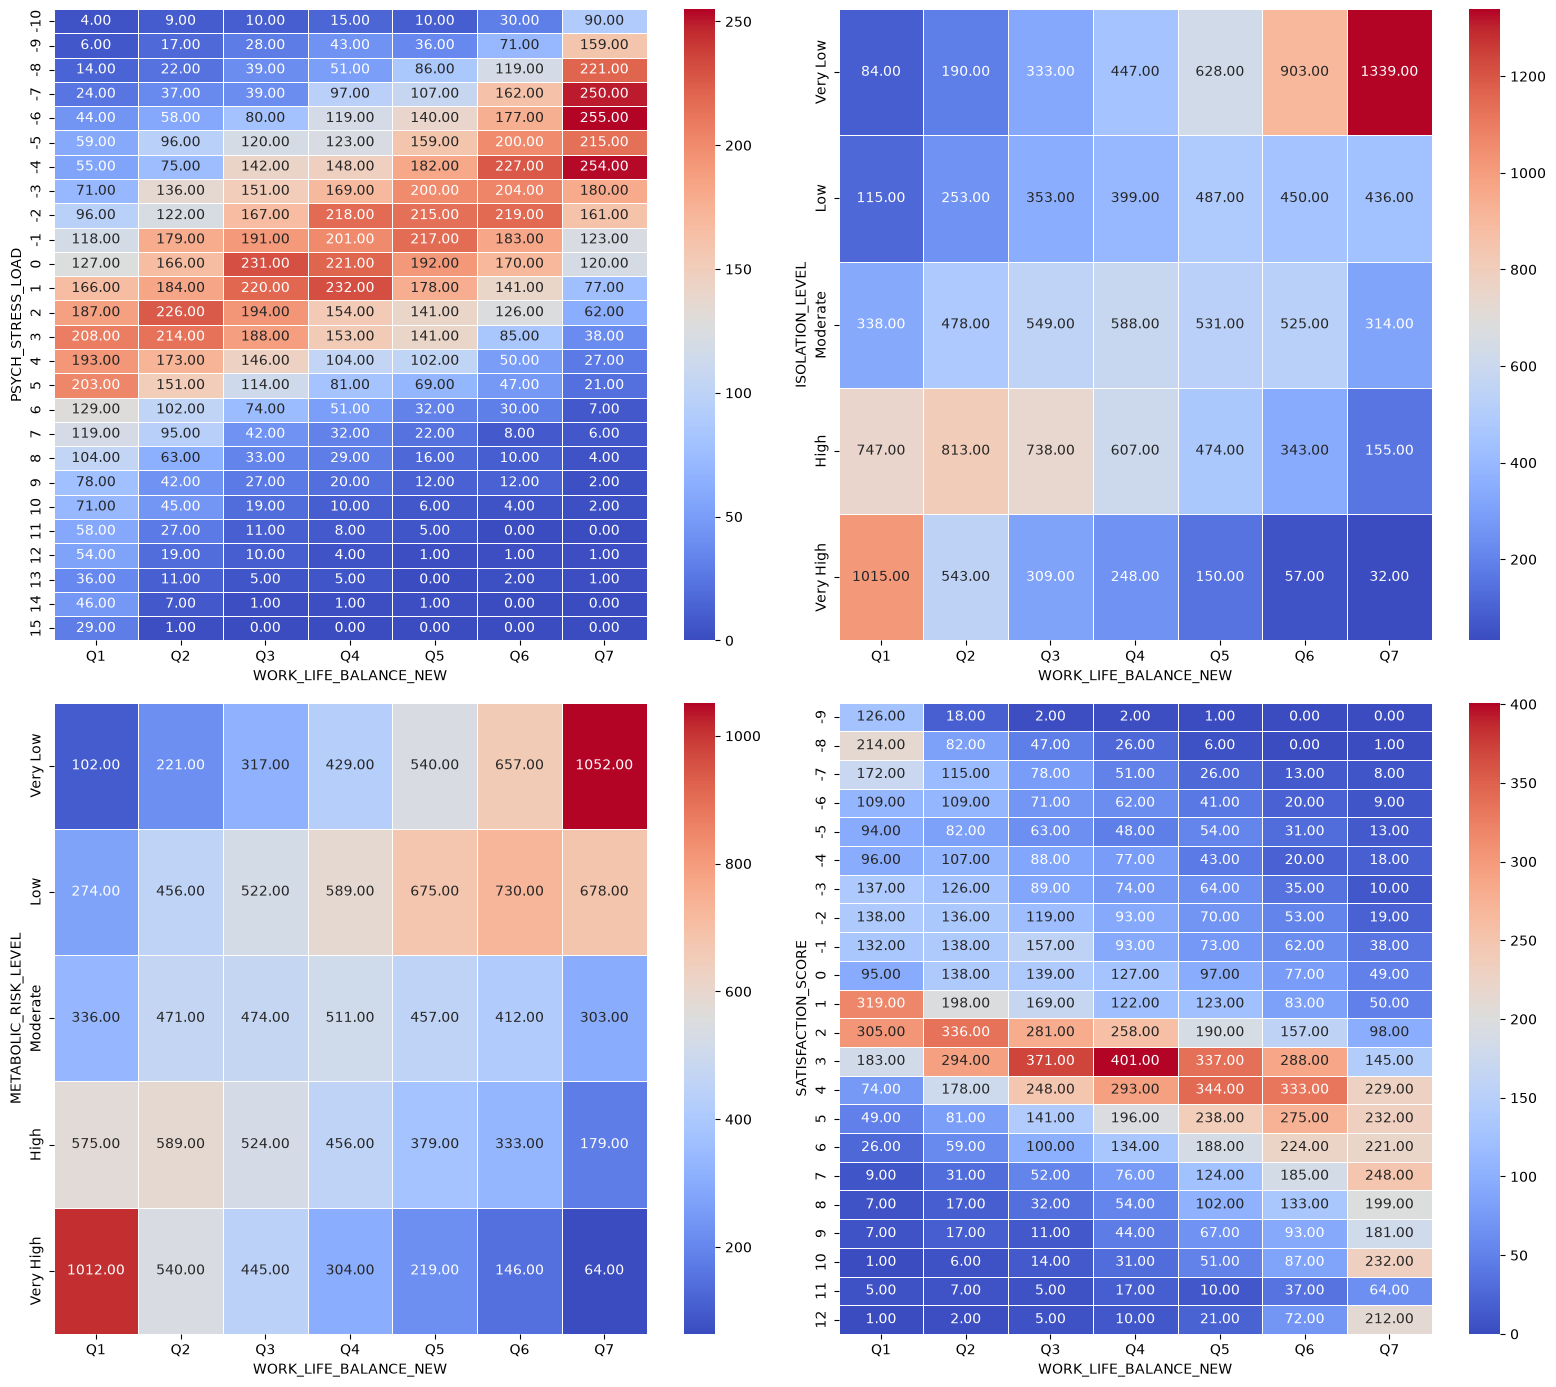

In [191]:
selected_features = ['PSYCH_STRESS_LOAD', 'ISOLATION_LEVEL', 'METABOLIC_RISK_LEVEL','SATISFACTION_SCORE']
plt.figure(figsize=(16,14))
for i, feature in enumerate(selected_features):
    plt.subplot(2,2,i+1)
    obser = pd.crosstab(df[feature],df['WORK_LIFE_BALANCE_NEW'])
    sns.heatmap(obser,  annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.tight_layout()
plt.show()

Variance explained by PC1: 18.88%
Variance explained by PC2: 7.82%
Total variance captured in this 2D plot: 26.69%


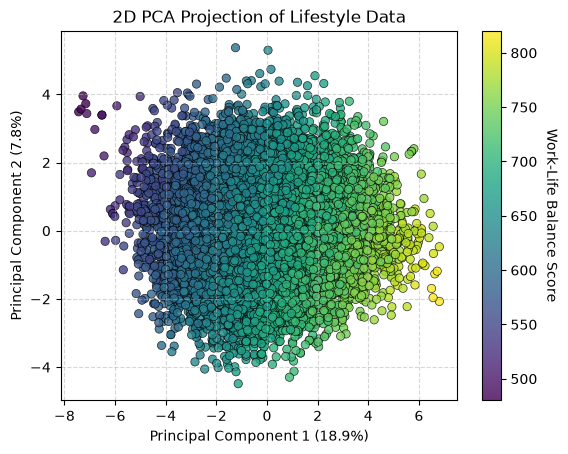

In [192]:
PCA_DF = pd.DataFrame(data = pca_full.transform(X_scaled)[:, :3], columns=['PC1', 'PC2', 'PC3'])
PCA_DF['Target'] = y.values

var_explained = pca_full.explained_variance_ratio_
print(f"Variance explained by PC1: {var_explained[0]*100:.2f}%")
print(f"Variance explained by PC2: {var_explained[1]*100:.2f}%")
print(f"Total variance captured in this 2D plot: {(var_explained[0]+var_explained[1])*100:.2f}%")
scatter = plt.scatter(PCA_DF['PC1'], PCA_DF['PC2'], c=PCA_DF['Target'], cmap='viridis', 
                      alpha=0.8, # Make dots slightly transparent to see overlapping
                      edgecolors='black', 
                      linewidth=0.5)

# Add a color bar to explain the colors
cbar = plt.colorbar(scatter)
cbar.set_label('Work-Life Balance Score', rotation=270, labelpad=15)

# Labels and Title
plt.xlabel(f'Principal Component 1 ({var_explained[0]*100:.1f}%)')
plt.ylabel(f'Principal Component 2 ({var_explained[1]*100:.1f}%)')
plt.title('2D PCA Projection of Lifestyle Data')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

In [193]:
from sklearn.cluster import KMeans


features = ['DAILY_STRESS',
'ACHIEVEMENT',
'SLEEP_HOURS',
'DAILY_STEPS',
'DAILY_SHOUTING',
'SUFFICIENT_INCOME',
'GENDER_Male',
'AGE',
'TIME_FOR_PASSION']

new_df = df[new_features[:-1]]

X_scaled2 = scaler.fit_transform(new_df)

wcss = []

for i in range(1,11):

    model = KMeans(n_clusters=i, random_state = 42, n_init=10)
    
    model.fit(X_scaled2)

    wcss.append(model.inertia_)

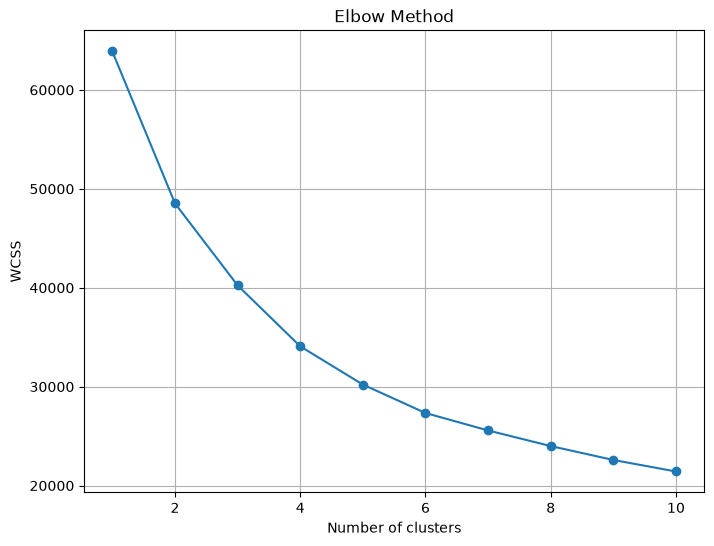

In [194]:
plt.figure(figsize=(8,6))

plt.plot(range(1,11), wcss, marker='o')

plt.title("Elbow Method")
plt.xlabel("Number of clusters")
plt.ylabel("WCSS")
plt.grid(True)
plt.show()

In [195]:
kmeans = KMeans(
    n_clusters=5,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(X_scaled2)

In [196]:
new_df['clusters'] = clusters
new_df.head(10)

,PSYCH_STRESS_LOAD,SOCIAL_ISOLATION_INDEX,METABOLIC_RISK_PROXY,SATISFACTION_SCORE,clusters
0,2,10,0.167,-4,2
1,-1,7,0.333,2,0
2,2,6,0.400,0,0
3,8,10,0.333,-4,2
4,-4,13,0.333,3,1
5,1,1,0.125,10,3
6,-8,4,0.250,0,3
7,4,10,0.111,4,0
8,-5,13,0.500,5,1
9,3,4,0.500,9,0


In [197]:
centers = scaler.inverse_transform(
    kmeans.cluster_centers_
)

cluster_centers = pd.DataFrame(
    centers,
    columns=new_features[:-1]
)

print(cluster_centers)

   PSYCH_STRESS_LOAD  SOCIAL_ISOLATION_INDEX  METABOLIC_RISK_PROXY  \
0           4.669277                6.836747              0.238150   
1          -2.904369               12.568194              0.235663   
2           0.905241                8.986810              0.243052   
3          -3.753264                3.834856              0.200592   
4           1.326056               10.320423              0.809189   

   SATISFACTION_SCORE  
0            2.772289  
1            3.559670  
2           -4.802846  
3            5.410357  
4            0.598592  


In [198]:
new_df['clusters'].value_counts()

clusters
3    4600
1    3754
0    3319
2    2879
4    1419
Name: count, dtype: int64

In [199]:
new_df.groupby('clusters')[new_features[:-1]].mean()

,PSYCH_STRESS_LOAD,SOCIAL_ISOLATION_INDEX,METABOLIC_RISK_PROXY,SATISFACTION_SCORE
clusters,,,,
0,4.675203,6.849955,0.238331,2.772221
1,-2.908098,12.567128,0.235607,3.557539
2,0.906217,8.979507,0.243103,-4.805488
3,-3.749565,3.835652,0.200566,5.408478
4,1.324172,10.318534,0.809407,0.596195


# Checking feature dominance

In [200]:
overall_mean = new_df[new_features[:-1]].mean()

overall_std = new_df[new_features[:-1]].std()

cluster_profile = (
    new_df.groupby('clusters')[new_features[:-1]].mean()
    - overall_mean
) / overall_std

print(cluster_profile)

          PSYCH_STRESS_LOAD  SOCIAL_ISOLATION_INDEX  METABOLIC_RISK_PROXY  \
clusters                                                                    
0                  1.064529               -0.243437             -0.189698   
1                 -0.492055                0.948453             -0.202589   
2                  0.290889                0.200522             -0.167115   
3                 -0.664778               -0.871846             -0.368429   
4                  0.376681                0.479677              2.513057   

          SATISFACTION_SCORE  
clusters                      
0                   0.130973  
1                   0.298099  
2                  -1.481662  
3                   0.692003  
4                  -0.332114  


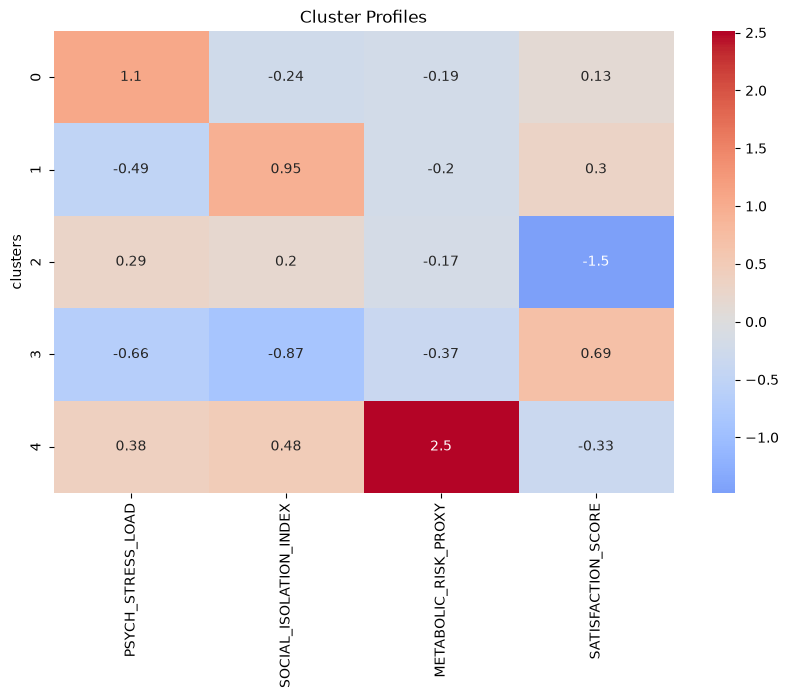

In [201]:
plt.figure(figsize=(10,6))

sns.heatmap(
    cluster_profile,
    annot=True,
    cmap="coolwarm",
    center=0
)

plt.title("Cluster Profiles")
plt.show()

In [202]:
feature_importance = cluster_profile.abs().max(axis=0)

feature_importance.sort_values(ascending=False)

METABOLIC_RISK_PROXY      2.513057
SATISFACTION_SCORE        1.481662
PSYCH_STRESS_LOAD         1.064529
SOCIAL_ISOLATION_INDEX    0.948453
dtype: float64

# SSE


In [203]:
# Plotting the sse of clusters

for cluster_id in range(kmeans.n_clusters):
    
    #selecting the cluster points
    cluster_points = X_scaled2[clusters == cluster_id]

    #Getting centroid
    cluster_centers =  kmeans.cluster_centers_[cluster_id]

    #Calculate SSE
    sse = np.sum((cluster_points-cluster_centers)**2)

    print(f"Cluster {cluster_id}: SSE = {sse:.2f}")

Cluster 0: SSE = 5901.00
Cluster 1: SSE = 5658.72
Cluster 2: SSE = 6455.06
Cluster 3: SSE = 7014.57
Cluster 4: SSE = 5182.13


# Daimeter

In [204]:
#Finding the diameter of the cluster

from sklearn.metrics import pairwise_distances_chunked

def cluster_diameter(points):

    max_distance = 0

    for distances in pairwise_distances_chunked(
        points,
        working_memory=256
    ):
        max_distance = max(
            max_distance,
            distances.max()
        )

    return max_distance


for cluster_id in range(kmeans.n_clusters):

    points = X_scaled2[clusters == cluster_id]

    diameter = cluster_diameter(points)

    print(
        f"Cluster {cluster_id}: "
        f"Diameter = {diameter:.3f}"
    )

Cluster 0: Diameter = 5.383
Cluster 1: Diameter = 5.344
Cluster 2: Diameter = 6.752
Cluster 3: Diameter = 5.308
Cluster 4: Diameter = 7.640


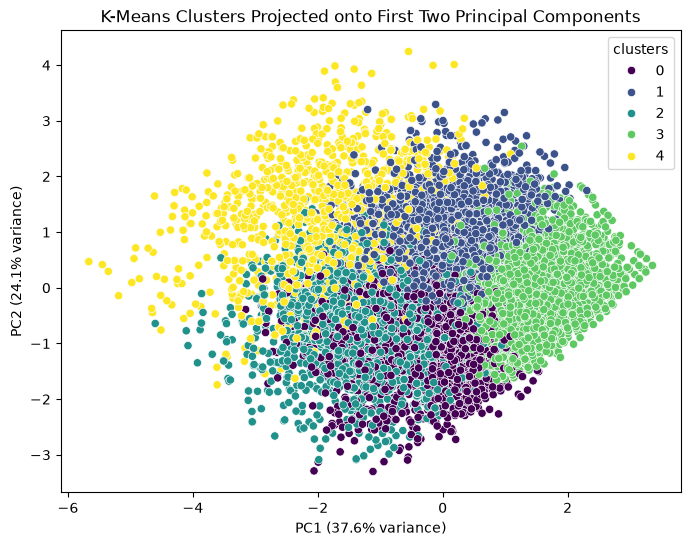

In [205]:
# from sklearn.decomposition import PCA

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled2)

plt.figure(figsize=(8,6))

sns.scatterplot(
    x=X_pca[:,0],
    y=X_pca[:,1],
    hue=new_df['clusters'],
    palette='viridis'
)

plt.xlabel(
    f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)"
)
plt.ylabel(
    f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)"
)
plt.title("K-Means Clusters Projected onto First Two Principal Components")

plt.show()

# Silhoutte Score

In [206]:
from sklearn.metrics import silhouette_score

score = silhouette_score(X_scaled2, clusters)

print(score)

0.2197244129521417


**The sillehoutte score here is around 12% which is a bad score and hence the kmeans clustering did not give us any meaning ful insight**

# davies_bouldin_score

In [207]:
from sklearn.metrics import davies_bouldin_score

score = davies_bouldin_score(X_scaled2, clusters)

print(score)

1.2923514958594988


# calinski_harabasz_score

In [208]:
from sklearn.metrics import calinski_harabasz_score

score = calinski_harabasz_score(X_scaled2, clusters)

print(score)

4448.780201125038


# Total variance captured by 2 pca components

In [209]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled2)
print(pca.explained_variance_ratio_)
print(sum(pca.explained_variance_ratio_))


cluster_pca_df = pd.DataFrame(
    X_pca,
    columns=["PC1", "PC2"],
)

cluster_pca_df['clusters'] = clusters

cluster_pca_df.head()

[0.37630778 0.24083694]
0.6171447229241818


,PC1,PC2,clusters
0,-0.964185,-0.726398,2
1,0.013568,0.043542,0
2,-0.591964,-0.421850,0
3,-1.948666,-1.064917,2
4,-0.122262,1.200486,1


The cumulative variance of both the principal component came out to be 33% which means that it only shows 33% of the data and 66% data is left behind

# plotting davies_bouldin_score & calinski_harabasz_score

In [210]:
ch_scores = []
db_scores = []

for i in range(2,11):

    kmeans = KMeans(n_clusters=i, random_state = 42, n_init=10)
    
    labels = kmeans.fit_predict(X_scaled2)

    ch_scores.append(calinski_harabasz_score(X_scaled2, labels))
    db_scores.append(davies_bouldin_score(X_scaled2, labels))

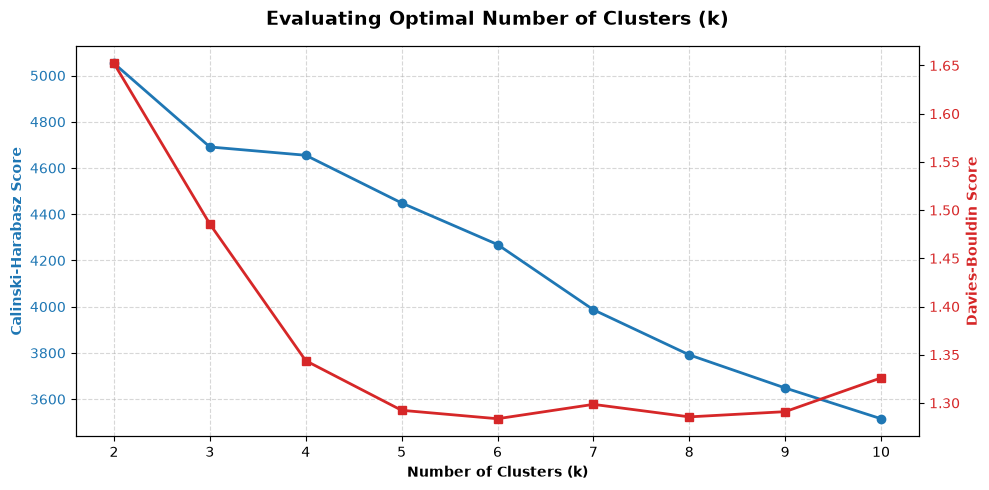

In [211]:
# Plot the evaluation metrics
fig, ax1 = plt.subplots(figsize=(10, 5))

# Plot Calinski-Harabasz Score (Higher is Better)
color = 'tab:blue'
ax1.set_xlabel('Number of Clusters (k)', fontweight='bold')
ax1.set_ylabel('Calinski-Harabasz Score', color=color, fontweight='bold')
ax1.plot(range(2, 11), ch_scores, marker='o', color=color, linewidth=2, label='CH Score (Maximize)')
ax1.tick_params(axis='y', labelcolor=color)
ax1.grid(True, linestyle='--', alpha=0.5)

# Instantiate a second axes that shares the same x-axis
ax2 = ax1.twinx()  

# Plot Davies-Bouldin Score (Lower is Better)
color = 'tab:red'
ax2.set_ylabel('Davies-Bouldin Score', color=color, fontweight='bold')
ax2.plot(range(2, 11), db_scores, marker='s', color=color, linewidth=2, label='DB Score (Minimize)')
ax2.tick_params(axis='y', labelcolor=color)

# Title and layout adjustments
plt.title('Evaluating Optimal Number of Clusters (k)', fontsize=14, fontweight='bold', pad=15)
fig.tight_layout()
plt.show()

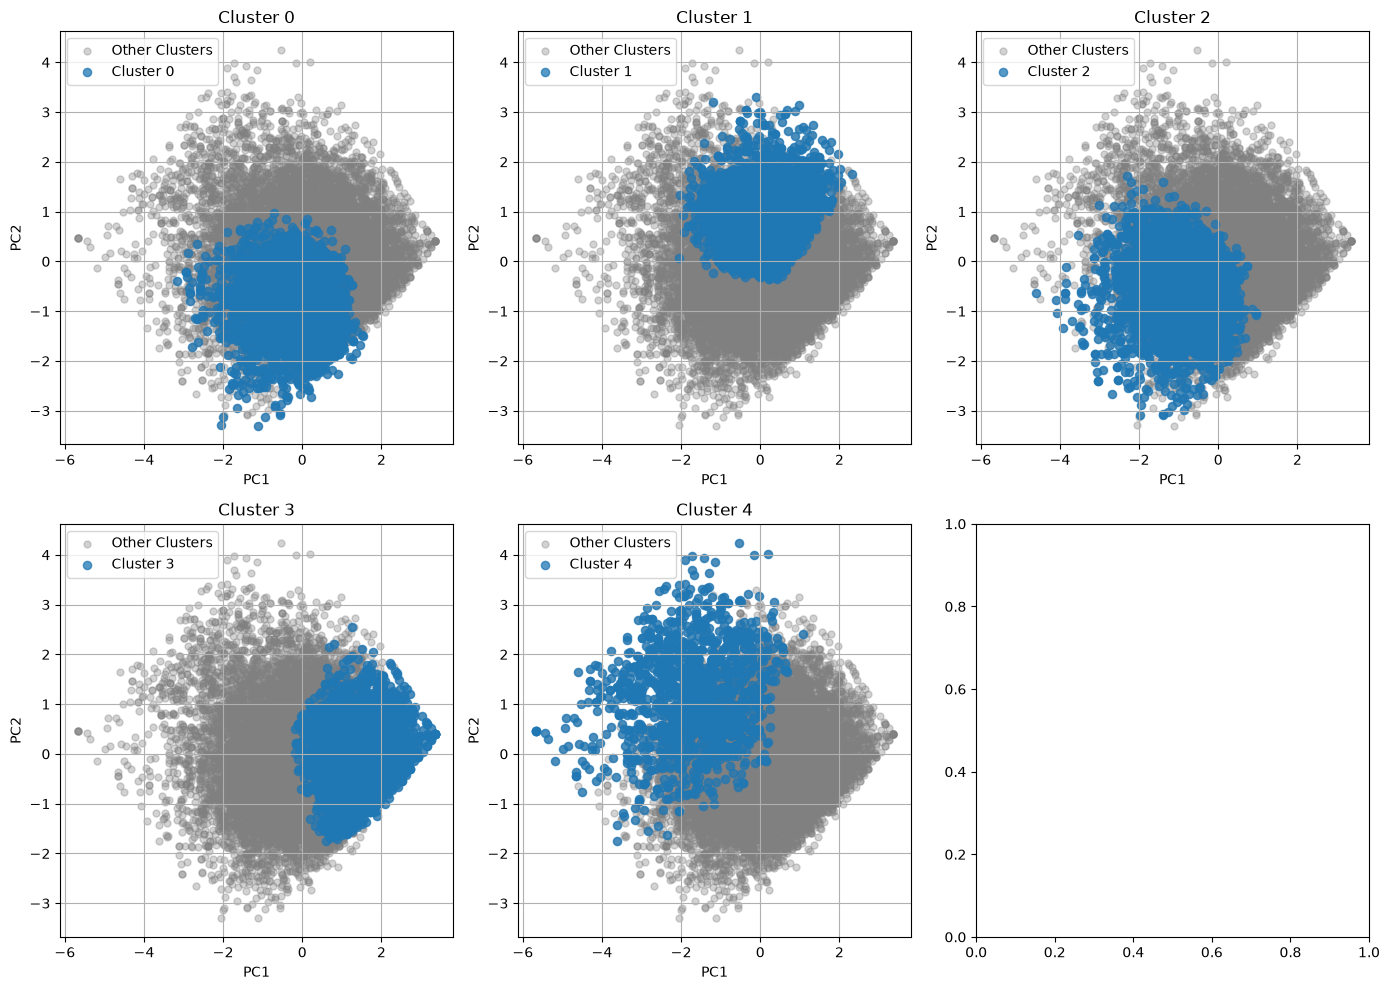

In [212]:
fig, axes = plt.subplots(2, 3, figsize=(14, 10))

axes = axes.ravel()

for cluster in sorted(cluster_pca_df["clusters"].unique()):

    ax = axes[cluster]

    # Plot all observations in light gray
    ax.scatter(
        cluster_pca_df["PC1"],
        cluster_pca_df["PC2"],
        color="gray",
        alpha=0.35,
        s=25,
        label="Other Clusters"
    )

    # Highlight the selected cluster
    subset = cluster_pca_df[
        cluster_pca_df["clusters"] == cluster
    ]

    ax.scatter(
        subset["PC1"],
        subset["PC2"],
        s=35,
        alpha=0.75,
        label=f"Cluster {cluster}"
    )

    ax.set_title(f"Cluster {cluster}")

    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")

    ax.grid(True)

    ax.legend()

plt.tight_layout()

plt.show()

In [213]:
cluster_profile

,PSYCH_STRESS_LOAD,SOCIAL_ISOLATION_INDEX,METABOLIC_RISK_PROXY,SATISFACTION_SCORE
clusters,,,,
0,1.064529,-0.243437,-0.189698,0.130973
1,-0.492055,0.948453,-0.202589,0.298099
2,0.290889,0.200522,-0.167115,-1.481662
3,-0.664778,-0.871846,-0.368429,0.692003
4,0.376681,0.479677,2.513057,-0.332114


In [214]:
engineered_features = [
    'PSYCH_STRESS_LOAD',
    'SOCIAL_ISOLATION_INDEX',
    'METABOLIC_RISK_PROXY',
    'SATISFACTION_SCORE'
]

# Mean value of each feature in each cluster
cluster_profile2 = new_df.groupby('clusters')[engineered_features].mean()

# Standardize the cluster means
scaler = StandardScaler()

cluster_profile_scaled = pd.DataFrame(
    scaler.fit_transform(cluster_profile2),
    columns=cluster_profile.columns,
    index=cluster_profile.index
)

# Creating the radar chart

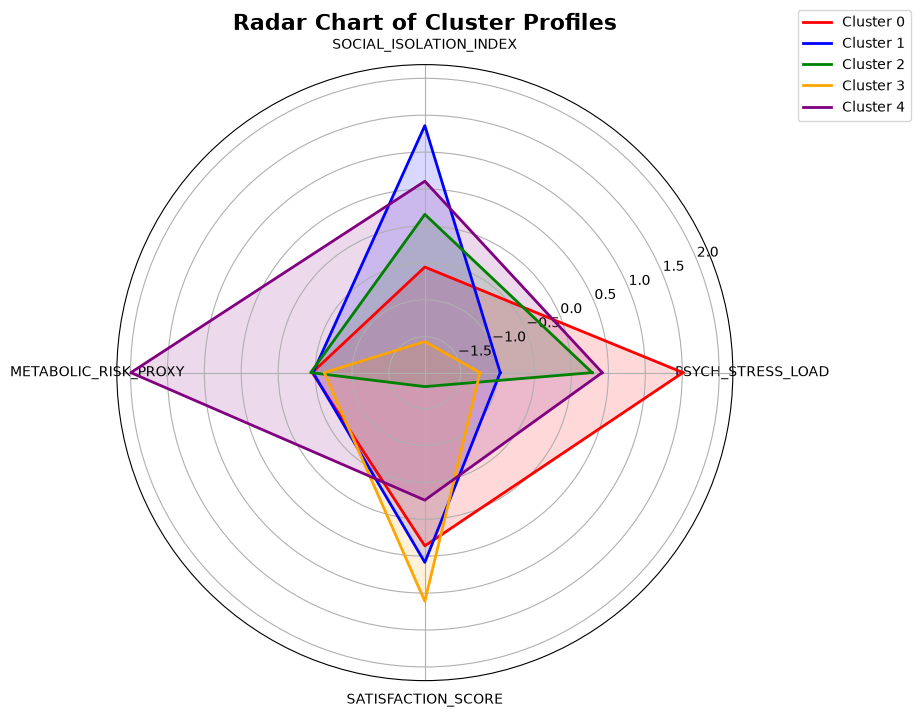

In [215]:
labels = cluster_profile_scaled.columns.tolist()

# Number of variables
num_vars = len(labels)

# Angle for each axis
angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()

# Close the circle
angles += angles[:1]

# Create figure
fig, ax = plt.subplots(figsize=(8,8), subplot_kw=dict(polar=True))

colors = ['red', 'blue', 'green', 'orange', 'purple']

for i, cluster in enumerate(cluster_profile_scaled.index):

    values = cluster_profile_scaled.loc[cluster].tolist()

    # Close the polygon
    values += values[:1]

    ax.plot(
        angles,
        values,
        linewidth=2,
        label=f'Cluster {cluster}',
        color=colors[i]
    )

    ax.fill(
        angles,
        values,
        alpha=0.15,
        color=colors[i]
    )

ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels, fontsize=10)

ax.set_title(
    "Radar Chart of Cluster Profiles",
    fontsize=16,
    fontweight='bold'
)

plt.legend(
    loc='upper right',
    bbox_to_anchor=(1.3,1.1)
)

plt.show()

In [216]:
from pandas.plotting import parallel_coordinates

# Convert index into a column
cluster_profile = cluster_profile.reset_index()

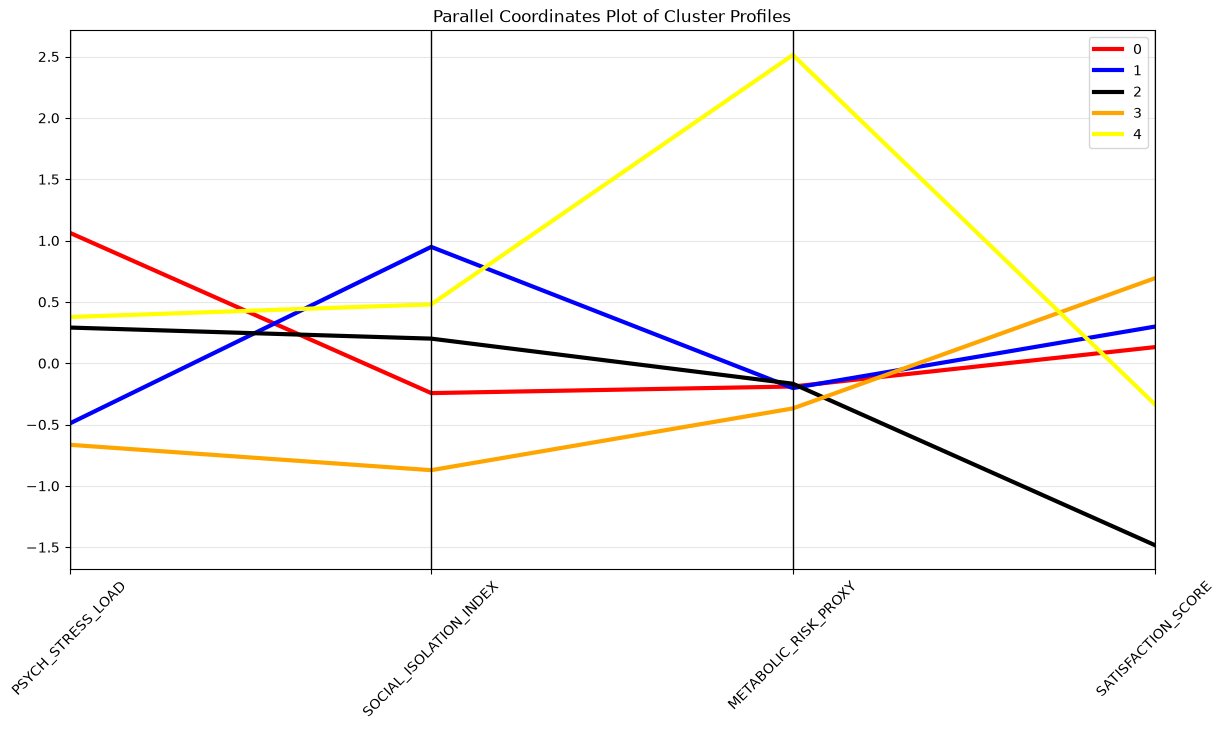

In [217]:


plt.figure(figsize=(14,7))

parallel_coordinates(
    cluster_profile,
    color=["red", "blue", "black","orange", "yellow"],
    class_column='clusters',
    linewidth=3
)

plt.title("Parallel Coordinates Plot of Cluster Profiles")

plt.grid(alpha=0.3)

plt.xticks(rotation=45)

plt.show()

# The kmeans clustering is not able to provide any meaningful insight and hence we will proceed to the next clustering scheme

In [218]:
df.head()

,FRUITS_VEGGIES,DAILY_STRESS,PLACES_VISITED,CORE_CIRCLE,SUPPORTING_OTHERS,SOCIAL_NETWORK,ACHIEVEMENT,DONATION,BMI_RANGE,TODO_COMPLETED,...,AGE,WORK_LIFE_BALANCE_SCORE,GENDER_Male,PSYCH_STRESS_LOAD,SOCIAL_ISOLATION_INDEX,METABOLIC_RISK_PROXY,SATISFACTION_SCORE,WORK_LIFE_BALANCE_NEW,ISOLATION_LEVEL,METABOLIC_RISK_LEVEL
0,3,2,2,5,0,5,2,0,1,6,...,2,609.5,False,2,10,0.167,-4,Q1,High,Low
1,2,3,4,3,8,10,5,2,2,5,...,2,655.6,False,-1,7,0.333,2,Q3,Moderate,High
2,2,3,3,4,4,10,3,2,2,2,...,2,631.6,False,2,6,0.400,0,Q2,Low,High
3,3,3,10,3,10,7,2,5,2,3,...,3,622.7,False,8,10,0.333,-4,Q2,High,High
4,5,1,3,3,10,4,2,4,2,5,...,3,663.9,False,-4,13,0.333,3,Q4,High,High


In [219]:
features_two = ['DAILY_STRESS',
'ACHIEVEMENT',
'SLEEP_HOURS',
'DAILY_STEPS',
'DAILY_SHOUTING', 
'AGE',
'TIME_FOR_PASSION']

new_df_two = df[features_two]

Before proceeding to the next clustering scheme i will examine the k means after dropping some features like gender and sufficient income 
